Tested with following versions:



*   Python 3.11.13
*   pandas version: 2.2.2
*   matplotlib version: 3.10.0
*   scikit-learn version: 1.6.1
*   numpy version: 2.0.2

In [1]:
# Import relevant packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.decomposition import PCA
from sklearn.utils import check_random_state

In [2]:
# Import data from dropbox
!wget -O FRED-monthly-2025-07.csv https://www.dropbox.com/scl/fi/qqw8frg6y7m84y2kn9n34/FRED-monthly-2025-07.csv?rlkey=d7nhg4s30eeh08e9rw0r6775g&dl=0

# Import
fred = pd.read_csv("FRED-monthly-2025-07.csv", encoding='latin1')
print(fred.head())

--2025-08-15 22:14:27--  https://www.dropbox.com/scl/fi/qqw8frg6y7m84y2kn9n34/FRED-monthly-2025-07.csv?rlkey=d7nhg4s30eeh08e9rw0r6775g
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc113b53cee0f72b7dd7e26b03db.dl.dropboxusercontent.com/cd/0/inline/CvdNdwkBOnK0gXjEcOKwsaFLsv0P1jHDxrdJCCdGDzBaMA63EwjBdHUV1gwkescCYVH2mc7RBMyfZHygjXo9Q0BZPWm-XKTLpfsfzaOp_UdRY_6NPFgYaQrDbAexfj_HQ_WmsFH6jXVBEh5hm9_HbcSq/file# [following]
--2025-08-15 22:14:28--  https://uc113b53cee0f72b7dd7e26b03db.dl.dropboxusercontent.com/cd/0/inline/CvdNdwkBOnK0gXjEcOKwsaFLsv0P1jHDxrdJCCdGDzBaMA63EwjBdHUV1gwkescCYVH2mc7RBMyfZHygjXo9Q0BZPWm-XKTLpfsfzaOp_UdRY_6NPFgYaQrDbAexfj_HQ_WmsFH6jXVBEh5hm9_HbcSq/file
Resolving uc113b53cee0f72b7dd7e26b03db.dl.dropboxusercontent.com (uc113b53cee0f72b7dd7e26b03db.dl.dropboxusercontent.com)... 162.125.

In [3]:
# Separate out date column
date = fred['Date']
fred = fred.drop(columns=['Date'])

# Find complete cases - i.e. find non-missing entries (coded as NaN)
complete = fred.dropna()

# Count missing cases
missing_count = fred.isna().sum().sum()
print(f"Total missing values in the dataset: {missing_count}")
total_cells = fred.size
missing_fraction = missing_count / total_cells
print(f"Fraction of missing values in the dataset: {missing_fraction:.4f}")

Total missing values in the dataset: 1002
Fraction of missing values in the dataset: 0.0100


In [4]:
# Iterative PCA Imputation

# Standardization helpers (based on training-observed only)
def compute_col_stats(X_np, mask):
    means = np.zeros(p)
    stds = np.ones(p)
    for j in range(p):
        col_vals = X_np[mask[:, j], j]
        if col_vals.size > 0:
            means[j] = np.nanmean(col_vals)
            s = np.nanstd(col_vals, ddof=0)
            stds[j] = s if s > 0 else 1.0
        else:
            means[j] = 0.0
            stds[j] = 1.0
    return means, stds

def standardize(X_np, means, stds):
    return (X_np - means) / stds

def destandardize(Z_np, means, stds):
    return Z_np * stds + means

def iterative_pca_em(Z_init, missing_mask, k, val_mask, max_iter=200, tol=1e-4, patience=10, verbose=False):
    """
    Z_init: standardized data with NaNs in missing & validation cells, real values elsewhere
    missing_mask: True for originally missing entries (to be imputed)
    val_mask: True for held-out observed entries (used for validation only; also imputed during training)
    Returns:
        Z_filled_best: standardized filled matrix at best validation MSE
        hist: list of val MSE per iteration
        best_iter: iteration index (0-based) where best MSE occurred
    """
    # Initialization: set missing & validation cells to column means => 0 in standardized scale
    Z_filled = Z_init.copy()
    Z_filled[np.isnan(Z_filled)] = 0.0

    best_mse = np.inf
    best_iter = -1
    best_Z = None
    hist = []
    no_improve = 0

    # For convergence check on parameter updates
    prev_val = None

    for it in range(max_iter):
        # Fit PCA on current fill
        pca_k = PCA(n_components=k, svd_solver="full", random_state=random_state)
        pca_k.fit(Z_filled)

        # Low-rank reconstruction
        Z_hat = pca_k.inverse_transform(pca_k.transform(Z_filled))

        # Update only missing + validation cells; keep observed-train cells fixed
        update_mask = missing_mask | val_mask
        Z_filled[update_mask] = Z_hat[update_mask]

        # Compute validation MSE on standardized scale
        # Only where we have true values (val_mask)
        diffs = Z_filled[val_mask] - Z_true[val_mask]
        val_mse = np.mean(diffs * diffs) if diffs.size > 0 else np.nan
        hist.append(val_mse)

        if verbose:
            print(f"[k={k}] Iter {it+1}: val MSE = {val_mse:.6f}")

        # Early stopping logic based on improvement
        if val_mse < best_mse - tol * (best_mse if np.isfinite(best_mse) and best_mse > 0 else 1.0):
            best_mse = val_mse
            best_iter = it
            best_Z = Z_filled.copy()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

        prev_val = val_mse

    # Fallback in case nothing improved
    if best_Z is None:
        best_Z = Z_filled.copy()
        best_iter = len(hist) - 1

    return best_Z, hist, best_iter, best_mse


In [5]:
# Hyperparameters
k_grid = list(range(1, 41))     # number of components to try
val_frac = 0.15                 # fraction of observed cells to hold out for validation
max_iter = 200
tol = 1e-4                      # relative improvement tolerance for early stopping
patience = 10                   # stop if no improvement for this many iters
random_state = 42

rng = check_random_state(random_state)

# Work on a copy that has missing values
X = fred.copy()
X_np = X.values.astype(float)
n, p = X_np.shape
obs_mask = ~np.isnan(X_np)

# Build a validation mask by holding out a random subset of observed cells
# keeping at least one observed per column if possible
val_mask = np.zeros_like(obs_mask, dtype=bool)
obs_idx = np.argwhere(obs_mask)
rng.shuffle(obs_idx)
n_val = int(val_frac * obs_idx.shape[0])
taken = 0
for i, j in obs_idx:
    if taken >= n_val: break
    val_mask[i, j] = True
    taken += 1

# Sanity: validation subset must be a subset of observed cells
val_mask &= obs_mask
train_obs_mask = obs_mask & (~val_mask)

# Compute stats from non-held-out observed cells
col_means, col_stds = compute_col_stats(X_np, train_obs_mask)

# Prepare standardized matrix and the “truth” for validation cells
Z_true = standardize(X_np, col_means, col_stds)  # standardized, still has NaNs

# Prepare standardized input with NaNs for originally missing and validation cells
Z_in = standardize(X_np, col_means, col_stds)
# Set NaN in both originally missing and validation cells
trainable_missing_mask = (~train_obs_mask)  # True where originally missing OR validation (since train_obs_mask excludes val)
Z_in[trainable_missing_mask] = np.nan

# Model selection over k by validation MSE with early stopping
k_results = []
best_overall = (None, np.inf, None, None)  # (k, best_val_mse, Z_best_std, hist)

for k in k_grid:
    Zk_best, hist, best_iter_k, best_mse_k = iterative_pca_em(
        Z_init=Z_in,
        missing_mask=(~obs_mask),   # originally missing cells
        k=k,
        val_mask=val_mask,
        max_iter=max_iter,
        tol=tol,
        patience=patience,
        verbose=False
    )
    k_results.append((k, best_mse_k, best_iter_k, hist))
    if best_mse_k < best_overall[1]:
        best_overall = (k, best_mse_k, Zk_best, hist)

best_k, best_val_mse, Z_best_std, best_hist = best_overall
print(f"Selected k = {best_k} with best validation MSE (standardized) = {best_val_mse:.6f}")

Selected k = 8 with best validation MSE (standardized) = 0.690843


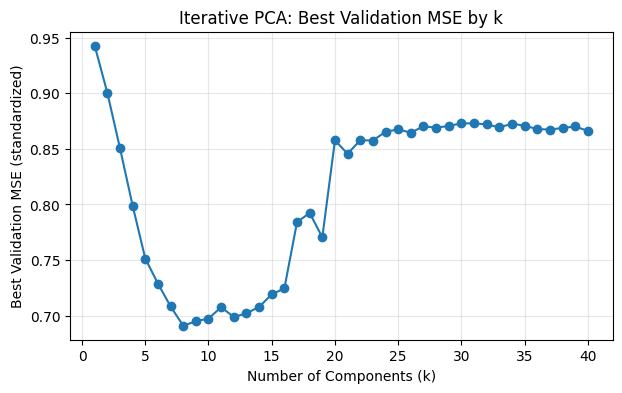

In [6]:
# Plot: best validation MSE vs k
plt.figure(figsize=(7, 4))
plt.plot([kr[0] for kr in k_results], [kr[1] for kr in k_results], marker='o')
plt.xlabel("Number of Components (k)")
plt.ylabel("Best Validation MSE (standardized)")
plt.title("Iterative PCA: Best Validation MSE by k")
plt.grid(True, alpha=0.3)
plt.show()

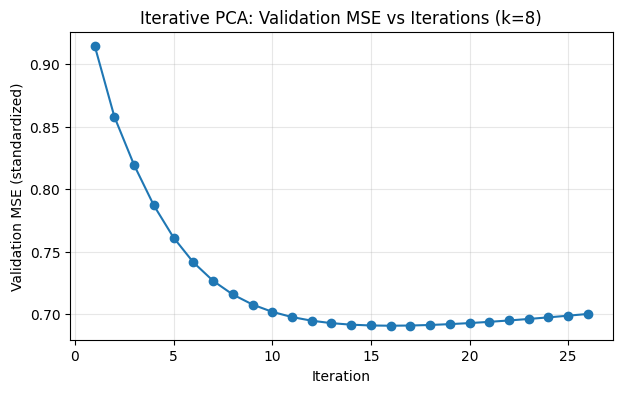

In [7]:
# Plot: validation MSE vs iteration for best k
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(best_hist)+1), best_hist, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Validation MSE (standardized)")
plt.title(f"Iterative PCA: Validation MSE vs Iterations (k={best_k})")
plt.grid(True, alpha=0.3)
plt.show()

Total missing values after imputation: 0


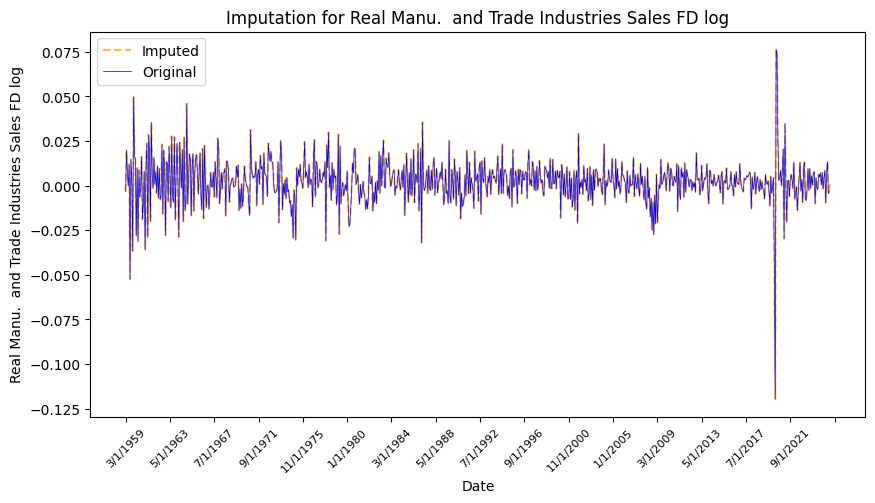

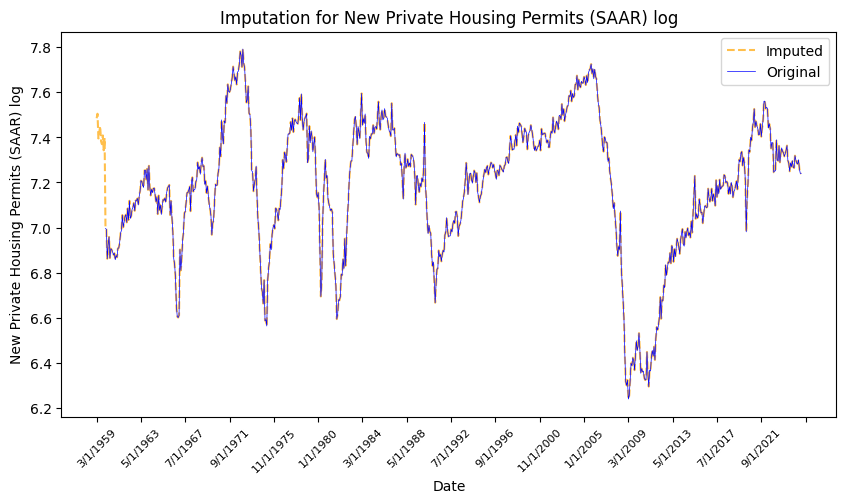

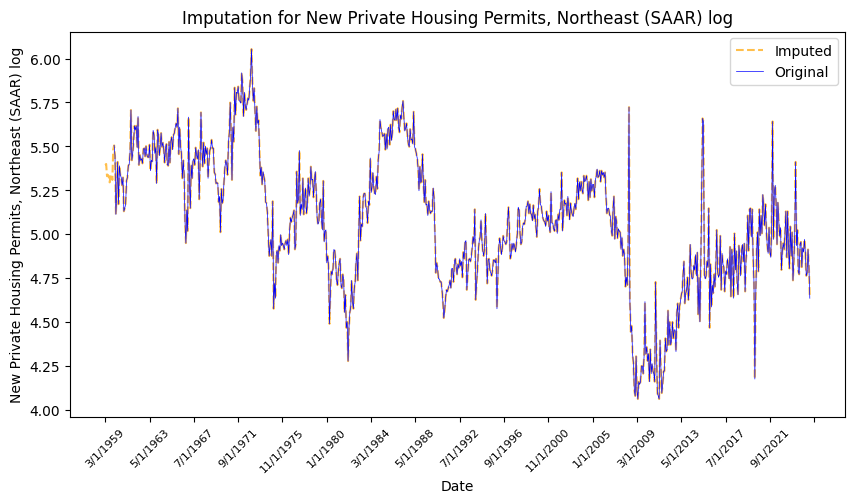

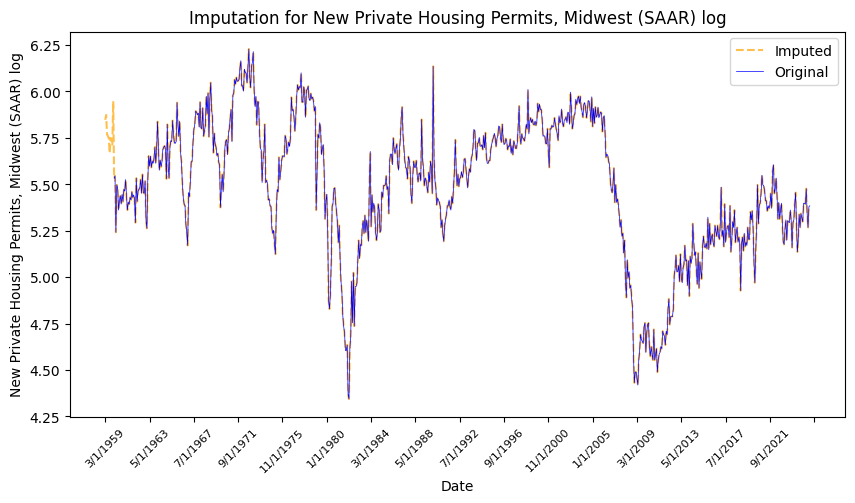

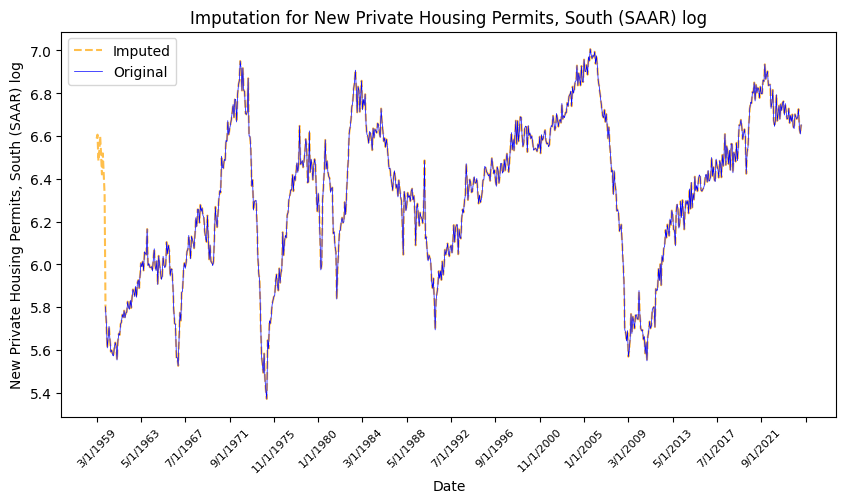

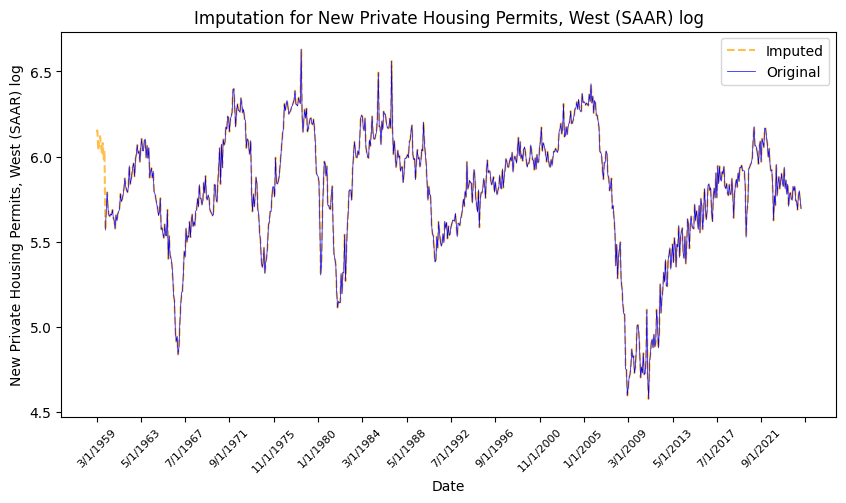

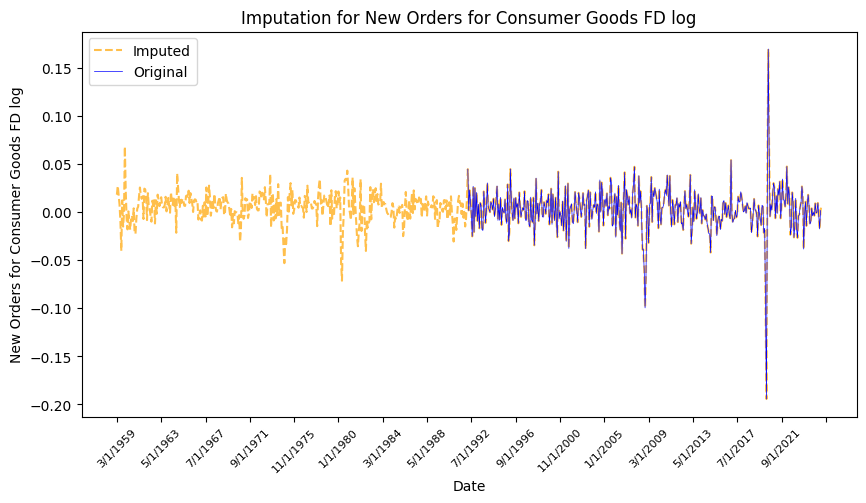

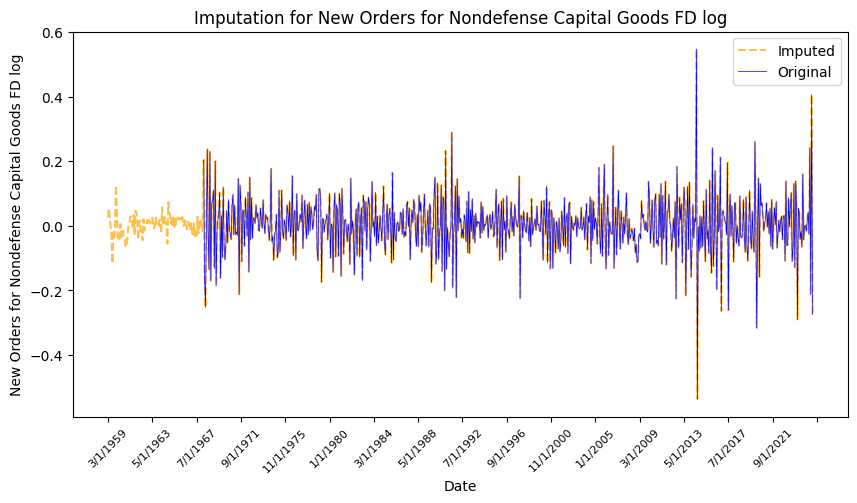

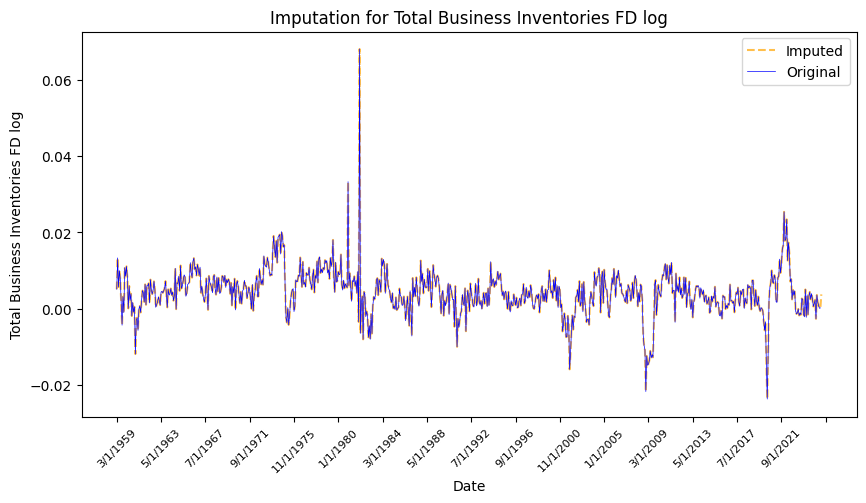

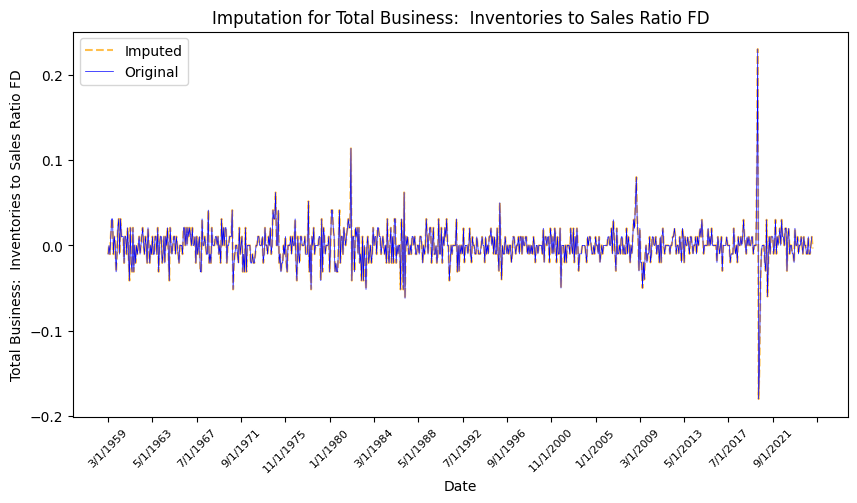

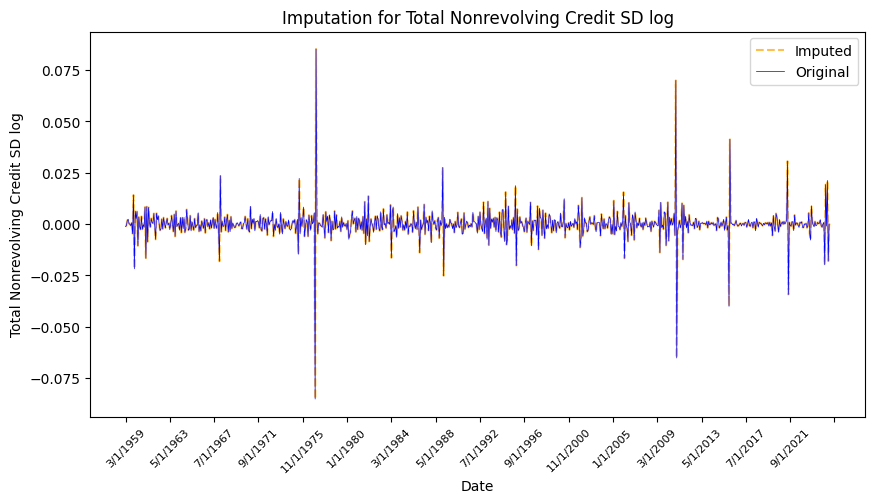

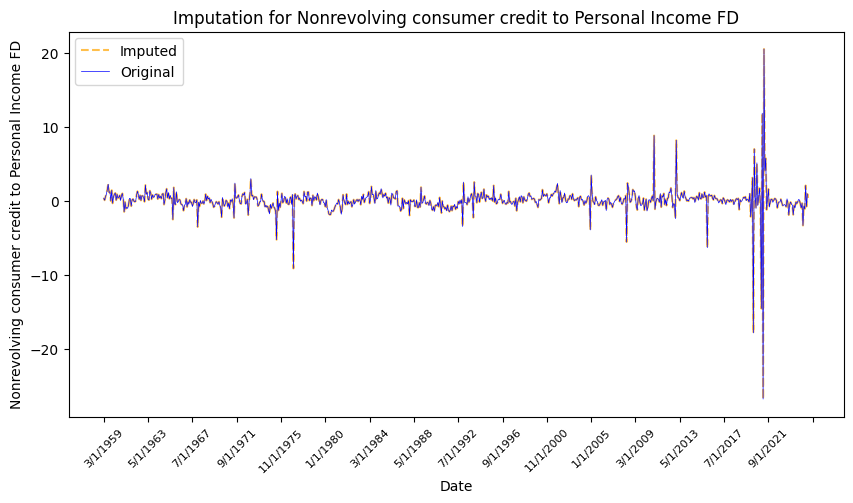

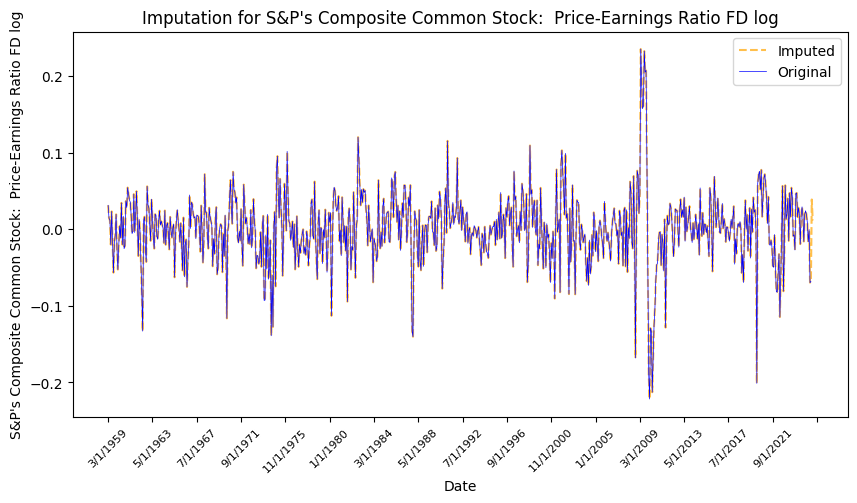

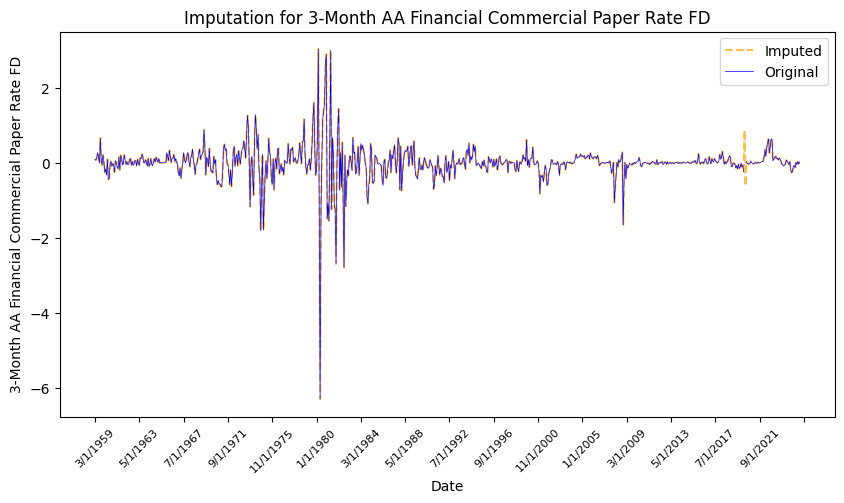

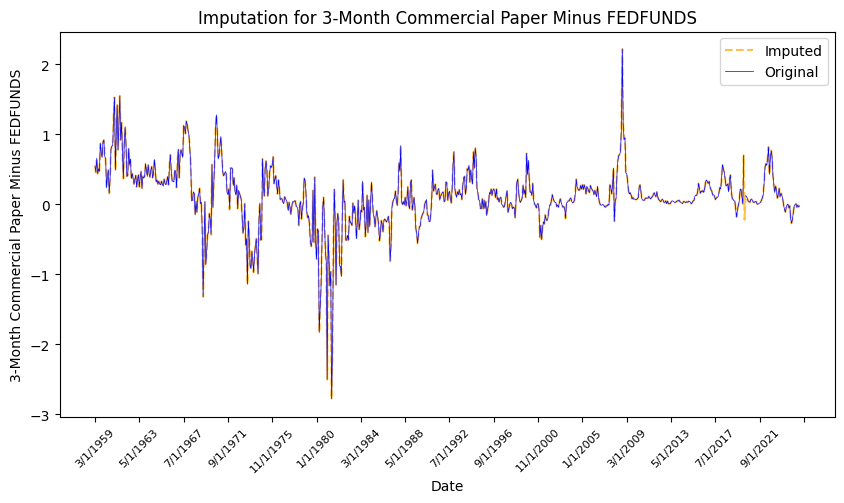

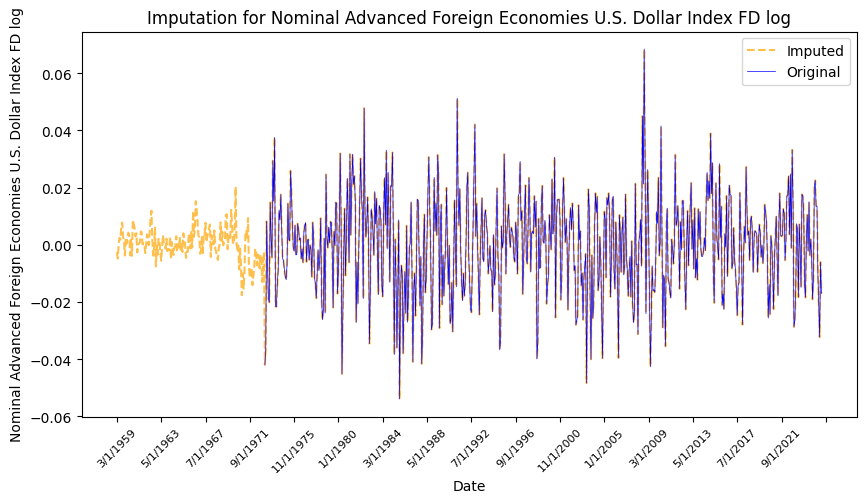

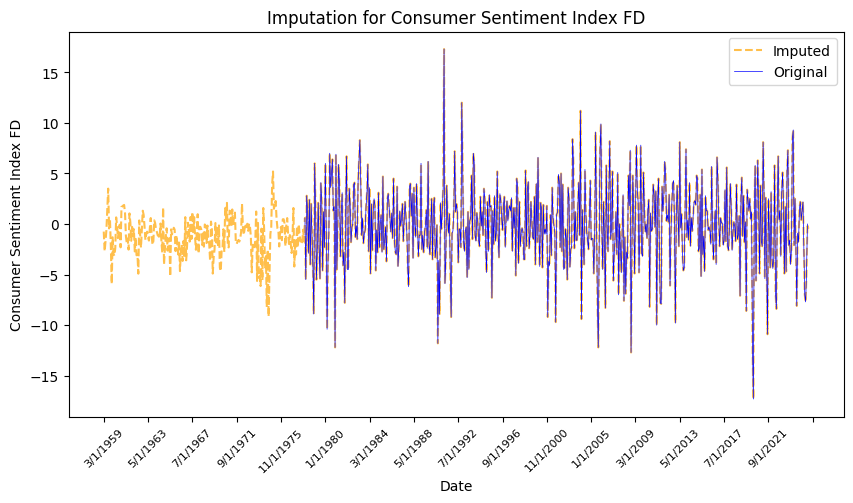

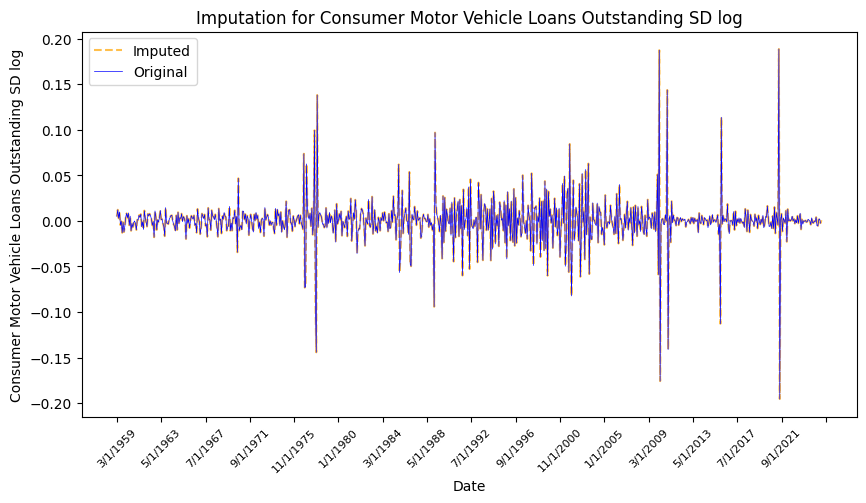

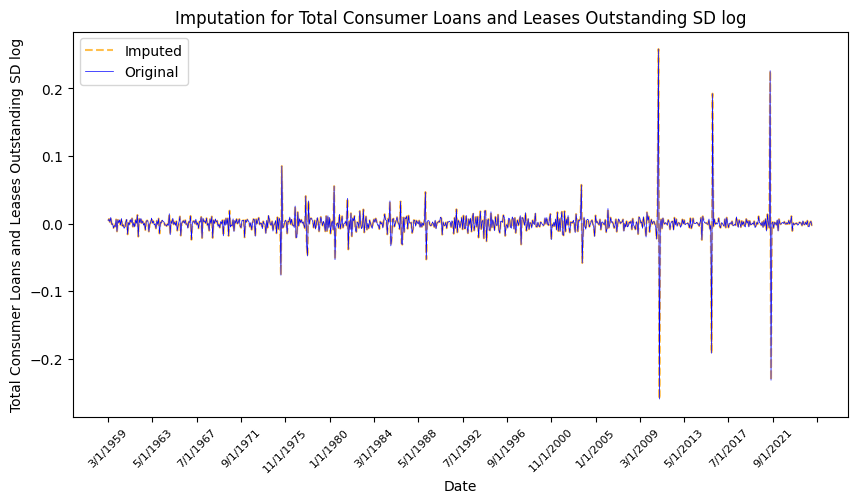

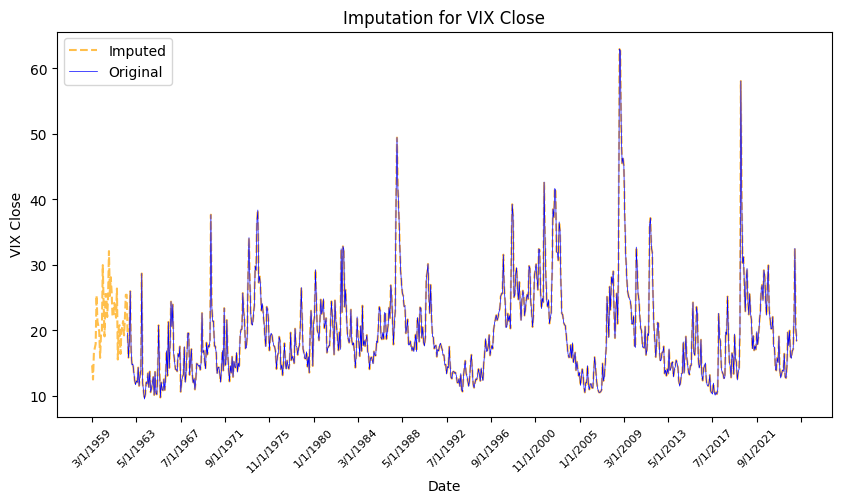

In [9]:
# De-standardize the best standardized fill (includes imputed missing + validation cells)
X_imputed_from_best = destandardize(Z_best_std, col_means, col_stds)

# Assemble DataFrame with original index/cols
fred_imputed = pd.DataFrame(X_imputed_from_best, columns=X.columns, index=X.index)

# Put the exact observed values back in
fred_imputed.values[obs_mask] = X_np[obs_mask]

# Save the imputed data
fred_imputed_with_date = pd.concat([date.reset_index(drop=True), fred_imputed.reset_index(drop=True)], axis=1)

# Count missing cases after imputation
missing_count_after = fred_imputed.isna().sum().sum()
print(f"Total missing values after imputation: {missing_count_after}")

# Find columns that originally had missing values
missing_columns = fred.columns[~obs_mask.all(axis=0)]
# Plot the imputed and original data for these columns
# Imputed values should be shown as dashed lines
for col in missing_columns:
    plt.figure(figsize=(10, 5))
    plt.plot(date, fred_imputed[col], label='Imputed', color='orange', alpha=0.7, linestyle='--')
    plt.plot(date, fred[col], label='Original', color='blue', linewidth = .5)
    plt.xticks(rotation=45, fontsize=8)
    plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=20, integer=True))
    clean_title = col.replace('\x92', "'").replace('\u2019', "'")  # Clean title for apostrophes
    plt.title(f"Imputation for {clean_title}")
    #plt.title(f"Imputation for {col}")
    plt.xlabel("Date")
    plt.ylabel(clean_title)
    plt.legend()
    plt.show()